In [ ]:
# library(ArchR)
# addArchRGenome("mm10")
# library(BSgenome.Mmusculus.UCSC.mm10)

# proj <- loadArchRProject(path = "data/snATAC_data/ArchRProject")
# se_gene <- getMatrixFromProject(proj, useMatrix = "GeneScoreMatrix")
# gene_mtx <- t(assay(se_gene)) 
# gene_names <- rowData(se_gene)$name
# cell_names <- colnames(se_gene)
# meta_df <- as.data.frame(getCellColData(proj))
# selected_genes <- c("Pax6", "Nrxn2", "Grik1", "Vsx2", "Arr3", "Opn1mw", "Onecut1", "Lhx1", "Slc1a3", "Aqp4", "Rbpms", "Slc17a6", "Rho", "Nrl")
# idx <- match(selected_genes, gene_names)
# gene_mtx_subset <- gene_mtx[, idx]
# write.csv(as.matrix(gene_mtx_subset), "data/snATAC_data/gene_scores_subset.csv")
# write.csv(meta_df, "data/snATAC_data/metadata.csv")

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
scores_df = pd.read_csv("data/snATAC_data/gene_scores_subset.csv", index_col=0)
meta_df = pd.read_csv("data/snATAC_data/metadata.csv", index_col=0)

In [3]:
adata = sc.AnnData(X=scores_df.loc[meta_df.index], obs=meta_df)

In [4]:
sc.pp.scale(adata, max_value=10)

In [5]:
markers = ['Pax6','Nrxn2','Gfap','Pdgfra','Grik1','Vsx2','Arr3','Opn1mw','Onecut1','Lhx1',
           'Hexb','Cx3cr1','Slc1a3','Aqp4','Rbpms','Slc17a6','Rho','Nrl']

In [6]:
adata.var_names = markers

In [8]:
import matplotlib.colors as mcolors

In [9]:
my_blues_rev = mcolors.LinearSegmentedColormap.from_list(
    "WhiteToLightBlue", 
    ["#f2f8ff", "#1b5bb5"]
)

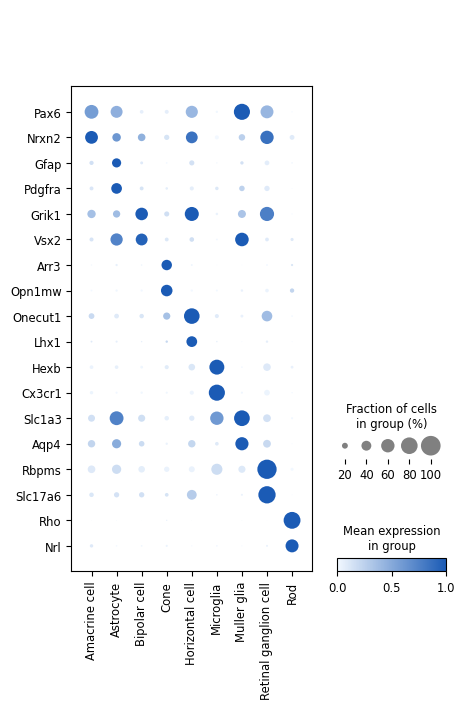

In [10]:
with plt.rc_context({"figure.figsize": (4, 8)}):
    sc.pl.dotplot(adata,markers,"Celltype",swap_axes=True,standard_scale='var',cmap=my_blues_rev, linewidth=0)

# for each celltype UMAP

In [12]:
umap_df = pd.read_csv("data/snATAC_data/archr_umap.csv", index_col=0)
adata.obsm['X_umap'] = umap_df.loc[adata.obs_names].values

In [13]:
markers = ['Pax6','Nrxn2','Gfap','Pdgfra','Grik1','Vsx2','Arr3','Opn1mw','Onecut1','Lhx1',
           'Hexb','Cx3cr1','Slc1a3','Aqp4','Rbpms','Slc17a6','Rho','Nrl']

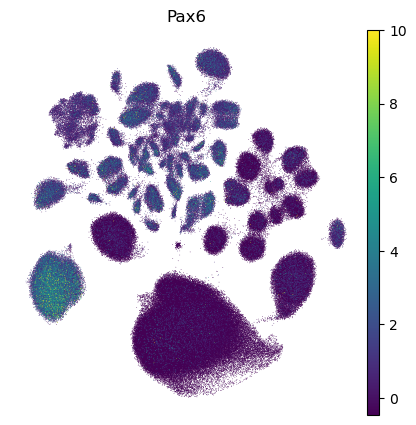

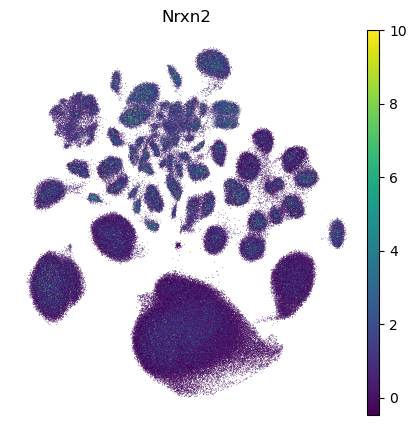

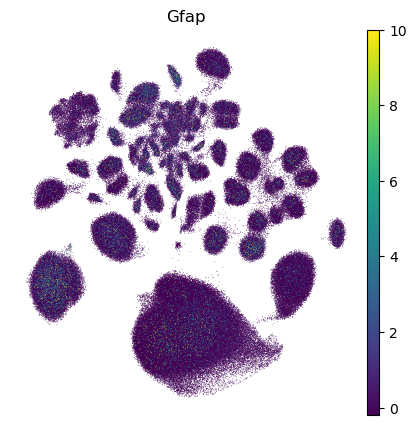

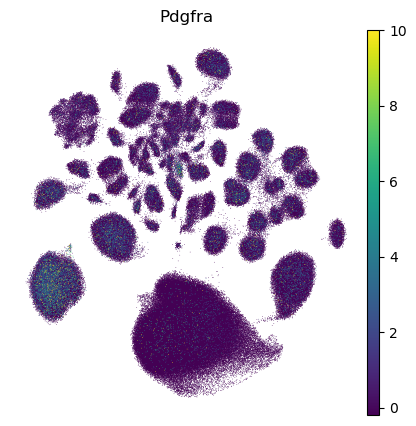

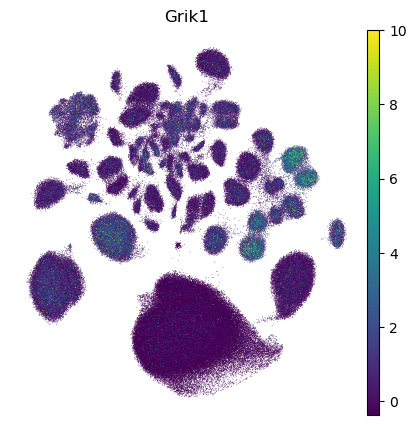

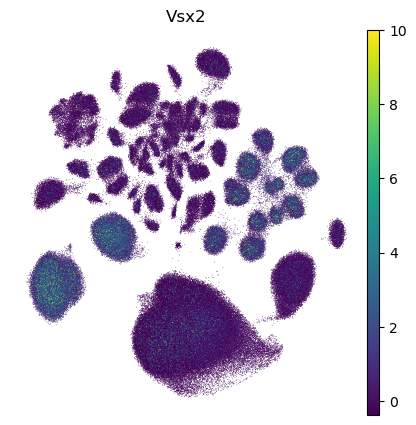

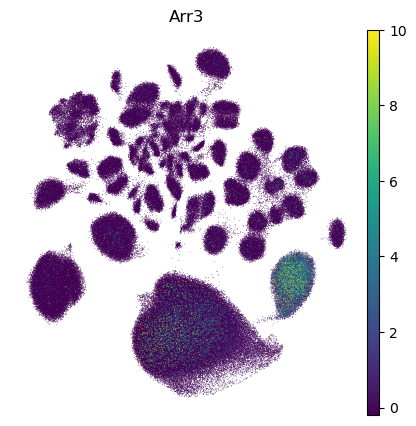

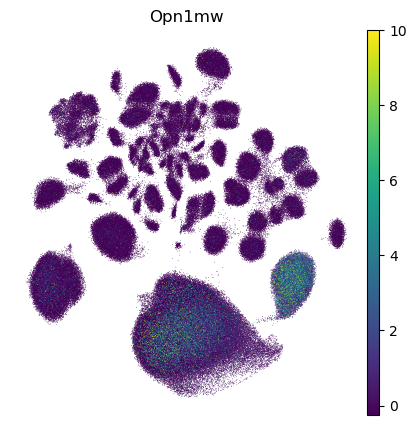

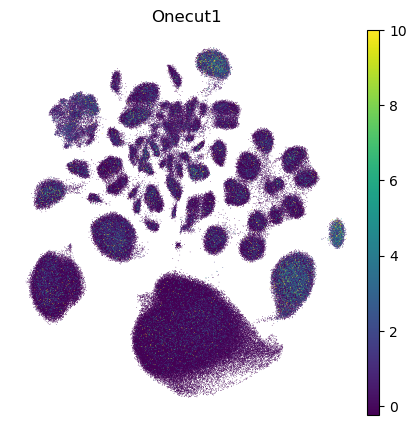

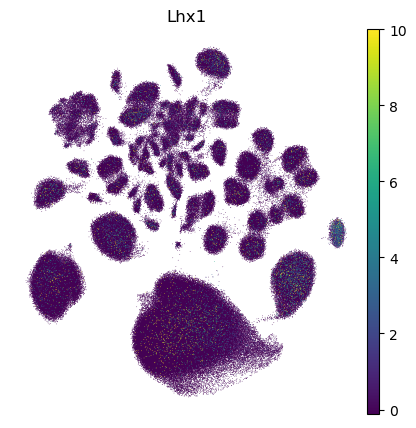

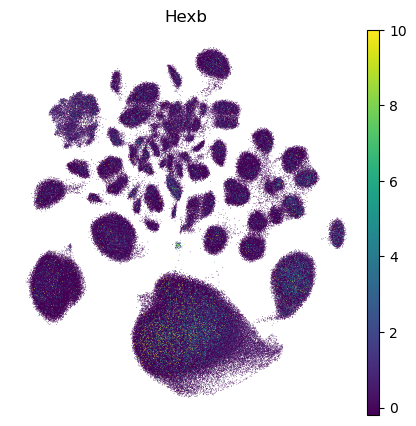

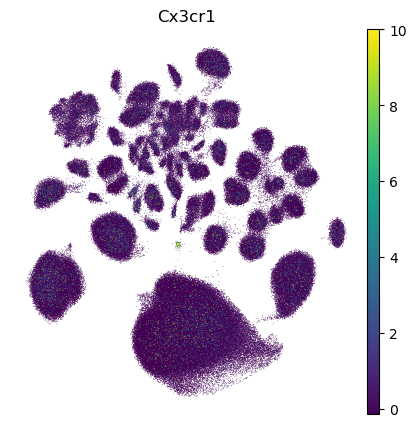

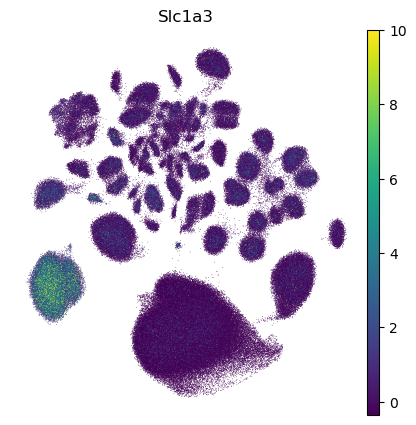

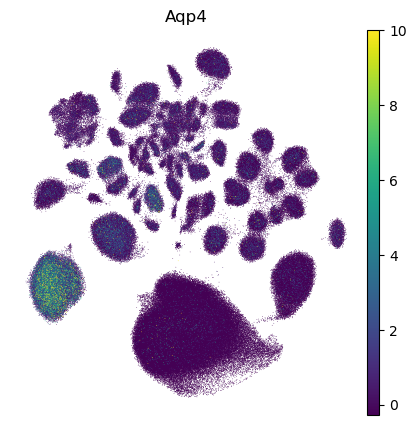

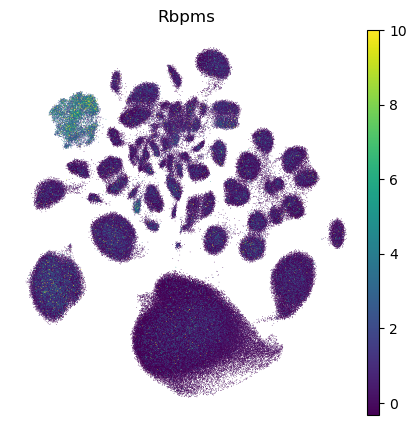

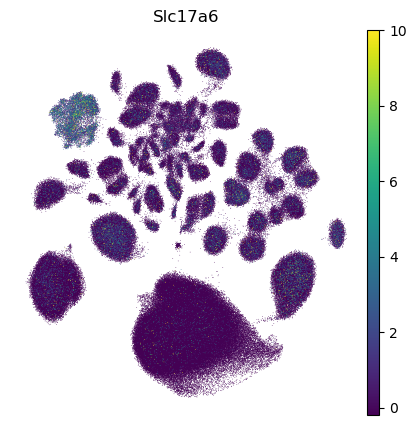

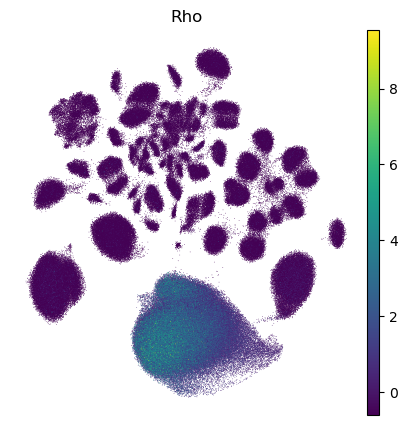

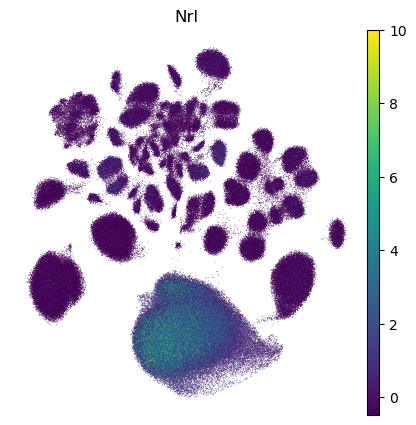

In [14]:
for i in markers:
    with plt.rc_context({"figure.figsize": (5, 5)}):
        sc.pl.umap(adata, color=i, frameon=False, size=1, alpha=1, show=True)